 **Assignment no.8. Model Improvement and Outlier Detection**

 **AIM:**

Use Different techniques for Detection of outliers (IQR and Z-score)
Residual Visualization
Detect multicollinearity using Variance Inflation Factor (VIF)
Improve model predictions using cleaned data.


**Lab Experiment 1** Give python code find mean, median, mode, first quartile, second quartile, third quartile, interquartile range and outliers for following distribution of Scores: 55, 60, 62, 70, 75, 78, 80, 82, 85, 90. use IQR and Z-score method to detect outliers

In [1]:
import numpy as np
from scipy import stats
import statistics
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dataset
scores = [55, 60, 62, 70, 75, 78, 80, 82, 85, 90]
data = np.array(scores)
print(f"Data: {scores}\n")

# 2. Measures of Central Tendency and Dispersion
mean = np.mean(data)
median = np.median(data)
# Mode can be tricky, statistics.mode handles it well
try:
    mode = statistics.mode(data)
except statistics.StatisticsError:
    mode = "No unique mode"

# 3. Quartiles and IQR
Q1 = np.percentile(data, 25)
Q2 = np.percentile(data, 50)  # Same as Median
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

print("--- Summary Statistics ---")
print(f"Mean: {mean:.2f}")
print(f"Median (Q2): {median:.2f}")
print(f"Mode: {mode}")
print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range (IQR): {IQR:.2f}\n")

# 4. Outlier Detection Techniques
print("--- Outlier Detection ---")

# Method A: Interquartile Range (IQR) - Traditional
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = data[(data < lower_bound) | (data > upper_bound)]
print(f"IQR Method Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"IQR Method Outliers: {iqr_outliers}")

# Method B: Z-Score Method (Threshold = 3)
# Z = (x - mean) / std_dev
z_scores = np.abs(stats.zscore(data))
z_outliers = data[z_scores > 3]
print(f"Z-Score Method Outliers (>3): {z_outliers}")

# Method C: Modified Z-Score Method (Robust, using Median and MAD)
# Best for small datasets with potential extreme outliers
median_score = np.median(data)
mad = np.median(np.abs(data - median_score)) # Median Absolute Deviation
# Modified Z-score formula: 0.6745 * (x - median) / MAD
# Using 3.5 as threshold
mod_z_scores = 0.6745 * (data - median_score) / mad
mod_z_outliers = data[np.abs(mod_z_scores) > 3.5]
print(f"Modified Z-Score Outliers (>3.5): {mod_z_outliers}")


Data: [55, 60, 62, 70, 75, 78, 80, 82, 85, 90]

--- Summary Statistics ---
Mean: 73.70
Median (Q2): 76.50
Mode: 55
First Quartile (Q1): 64.00
Third Quartile (Q3): 81.50
Interquartile Range (IQR): 17.50

--- Outlier Detection ---
IQR Method Bounds: [37.75, 107.75]
IQR Method Outliers: []
Z-Score Method Outliers (>3): []
Modified Z-Score Outliers (>3.5): []


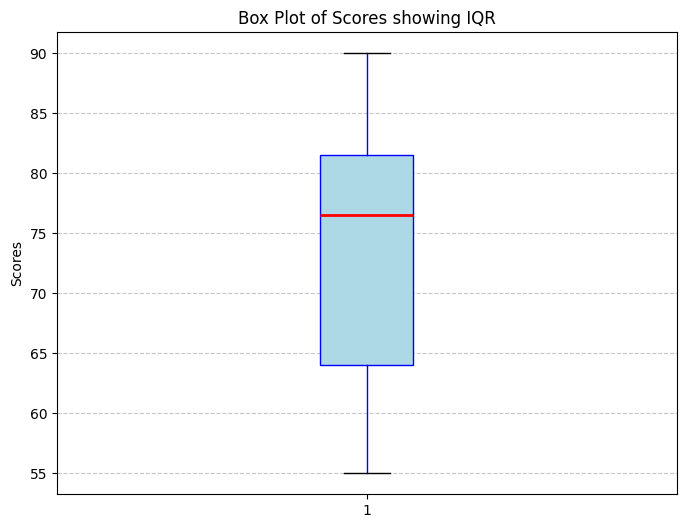

In [2]:
# 4. Box Plot Visualization
plt.figure(figsize=(8, 6))
plt.boxplot(scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            whiskerprops=dict(color='blue'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Box Plot of Scores showing IQR')
plt.ylabel('Scores')
plt.grid(axis='y', linestyle='--', alpha=0.7)



Mean: 73.7
Median (Q2): 76.5
Quartiles: Q1 is 64
 and Q3 is 81.5
.
IQR: 17.5*(81.5-64.0).
Outliers: No outliers were detected using either the IQR method (threshold:<37.5
 or >107.5
) or the Z-score method.

**Lab Experiment 2** Give python code find mean, median, mode, first quartile, second quartile, third quartile, interquartile range and outliers for following distribution of Scores: 55, 60, 62, 70, 75, 78, 80, 82, 1000, 5000. use all techniques to detect outliers

------------------------------
Descriptive Statistics
------------------------------
Mean: 656.20
Median: 76.50
Mode: 55.00
First Quartile (Q1): 64.00
Second Quartile (Median): 76.50
Third Quartile (Q3): 81.50
Interquartile Range (IQR): 17.50
------------------------------
Outliers Detected (IQR Method):
[1000, 5000]
Lower Bound: 37.75
Upper Bound: 107.75


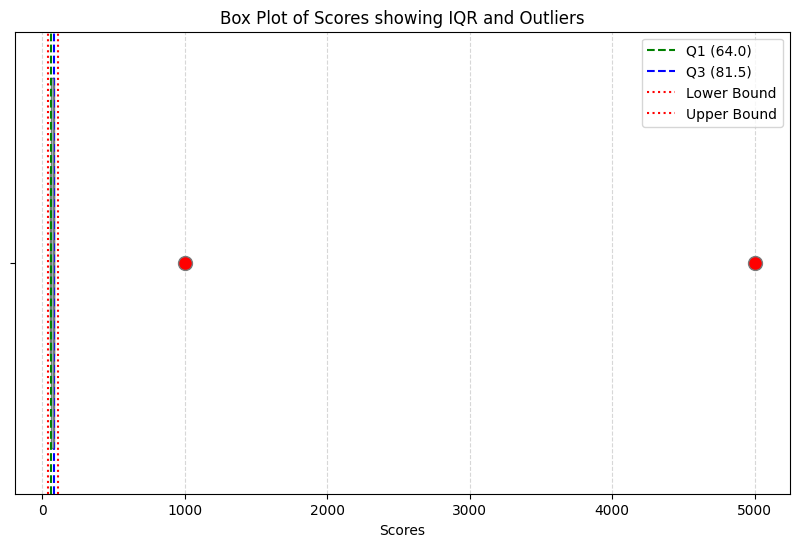

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Dataset
scores = [55, 60, 62, 70, 75, 78, 80, 82, 1000, 5000]
data = pd.Series(scores)

# 2. Find Descriptive Statistics
mean = data.mean()
median = data.median()
mode = data.mode()[0]  # Mode might be empty if all are unique
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# 3. Detect Outliers (IQR Method)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Using pandas boolean indexing to find outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

print("-" * 30)
print("Descriptive Statistics")
print("-" * 30)
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Mode: {mode:.2f}")
print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Second Quartile (Median): {median:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range (IQR): {IQR:.2f}")
print("-" * 30)
print("Outliers Detected (IQR Method):")
print(outliers.to_list())
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

# 4. Plot Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=data, color='lightblue', flierprops={"marker": "o", "markersize": 10, "markerfacecolor": "red"})

# Annotate IQR and bounds
plt.axvline(Q1, color='green', linestyle='--', label=f'Q1 ({Q1})')
plt.axvline(Q3, color='blue', linestyle='--', label=f'Q3 ({Q3})')
plt.axvline(lower_bound, color='red', linestyle=':', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle=':', label='Upper Bound')

plt.title('Box Plot of Scores showing IQR and Outliers')
plt.xlabel('Scores')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


**Lab Experiment 3** Find Inter-quartile range manually for the following dataset


data = [5, 8, 15, 26, 10, 18, 3, 12, 6, 14, 11]

In [4]:
import statistics

data = [5, 8, 15, 26, 10, 18, 3, 12, 6, 14, 11]
data.sort()

# Find the split point (median)
mid = len(data) // 2

# Split into halves (excluding middle element if odd)
lower_half = data[:mid]
upper_half = data[mid + 1:] if len(data) % 2 != 0 else data[mid:]

q1 = statistics.median(lower_half)
q3 = statistics.median(upper_half)
manual_iqr = q3 - q1

print(f"Manual IQR: {manual_iqr}")


Manual IQR: 9


**Lab Experiment 4** Generate two random datasets and using seaborn plot box plot and voilen plot for the datasets

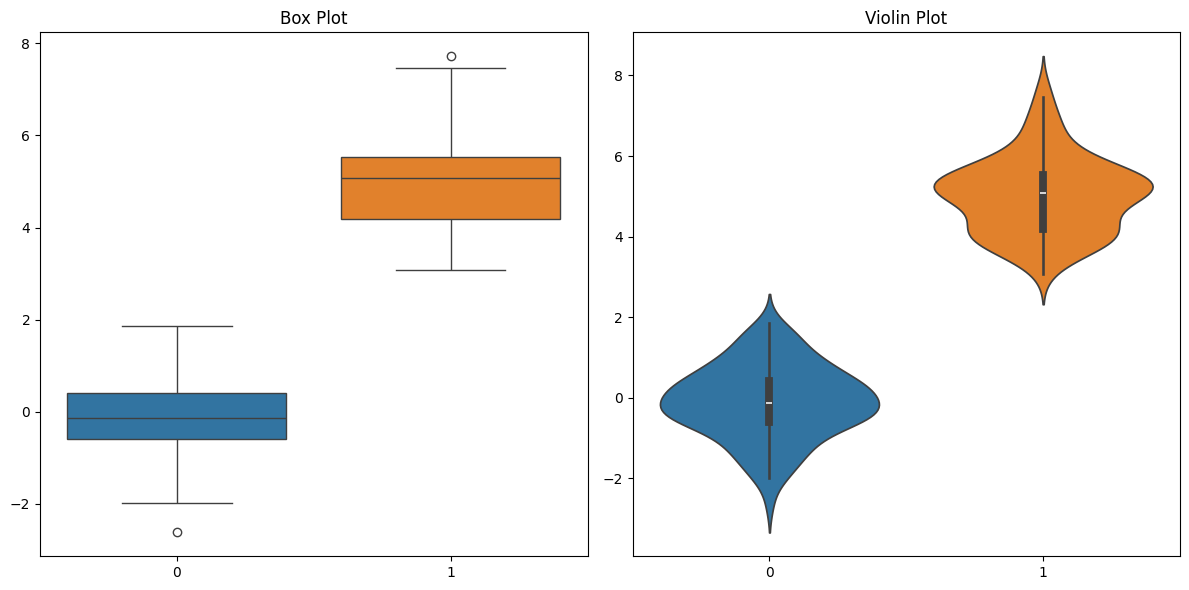

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generating random data
np.random.seed(42)
data1 = np.random.normal(0, 1, 100)
data2 = np.random.normal(5, 1, 100)

# Creating a figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plotting Boxplot
sns.boxplot(data=[data1, data2], ax=ax[0])
ax[0].set_title("Box Plot")

# Plotting Violinplot
sns.violinplot(data=[data1, data2], ax=ax[1])
ax[1].set_title("Violin Plot")

# Displaying the plots
plt.tight_layout()
plt.show()


**Residuals** are the differences between the observed values and the values predicted by your model. They are like the “leftover” errors after your model has made its best guess.

**Error Metrics** quantify these residuals to give you a clear picture of your model’s accuracy. Common metrics include Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

Plot the residuals for the following dataset:
data = pd.DataFrame({
    'Size': [1500, 1800, 2400, 3000, 3500, 4000, 4200, 5000],
    'Price': [300000, 350000, 450000, 550000, 600000, 650000, 700000, 800000]
})

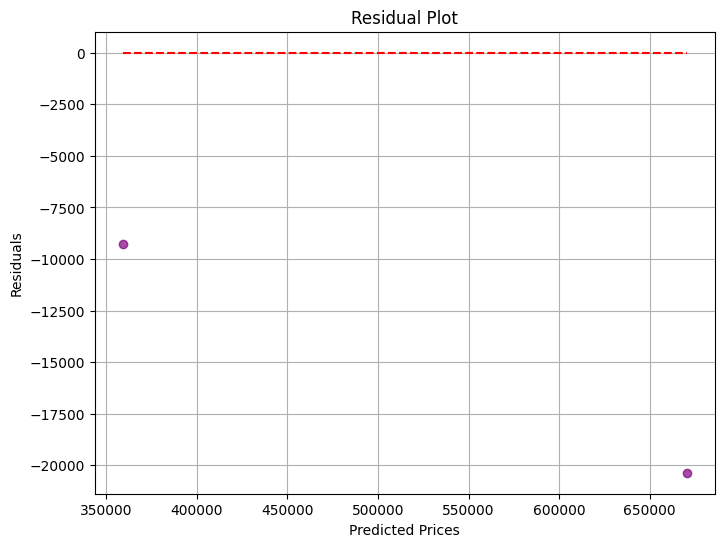

Residuals:
1    -9271.803556
5   -20364.098222
Name: Price, dtype: float64


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Sample dataset: House size (sq ft) and price (in dollars)
data = pd.DataFrame({
    'Size': [1500, 1800, 2400, 3000, 3500, 4000, 4200, 5000],
    'Price': [300000, 350000, 450000, 550000, 600000, 650000, 700000, 800000]
})

# Split the data
X = data[['Size']]
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions on the test set
predictions = model.predict(X_test)

# Calculate residuals
residuals = y_test - predictions

# Create a residual plot
plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, color='purple', alpha=0.7)
plt.hlines(y=0, xmin=predictions.min(), xmax=predictions.max(), colors='red', linestyles='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

print("Residuals:")
print(residuals)



In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate error metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error (MSE): 250331418.79
Root Mean Squared Error (RMSE): 15821.87
Mean Absolute Error (MAE): 14817.95
R-squared: 0.99


**Plotting the residues using seaborn.residplot**
seaborn.residplot(data=None, *, x=None, y=None, x_partial=None, y_partial=None, lowess=False, order=1, robust=False, dropna=True, label=None, color=None, scatter_kws=None, line_kws=None, ax=None)
Plot the residuals of a linear regression.

This function will regress y on x (possibly as a robust or polynomial regression) and then draw a scatterplot of the residuals. You can optionally fit a lowess smoother to the residual plot, which can help in determining if there is structure to the residuals.

**Lab Experiment 5-a** Detect multicollinearity using Variance Inflation Factor (VIF)
Improve model predictions using cleaned data. Also plot residual plot for Ambience v/s Offers for data.


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

retail_data = pd.read_csv('/content/vif_data.csv')
retail_data.head()

,Ambience,Customer_service,Offers,Product_range,Performance
0,0.50,1.40,-0.68,0.48,2
1,-0.14,0.92,-0.14,0.11,7
2,0.65,0.06,-0.79,0.51,5
3,1.52,-0.65,-0.31,1.12,9
4,-0.23,0.70,-1.89,1.10,8


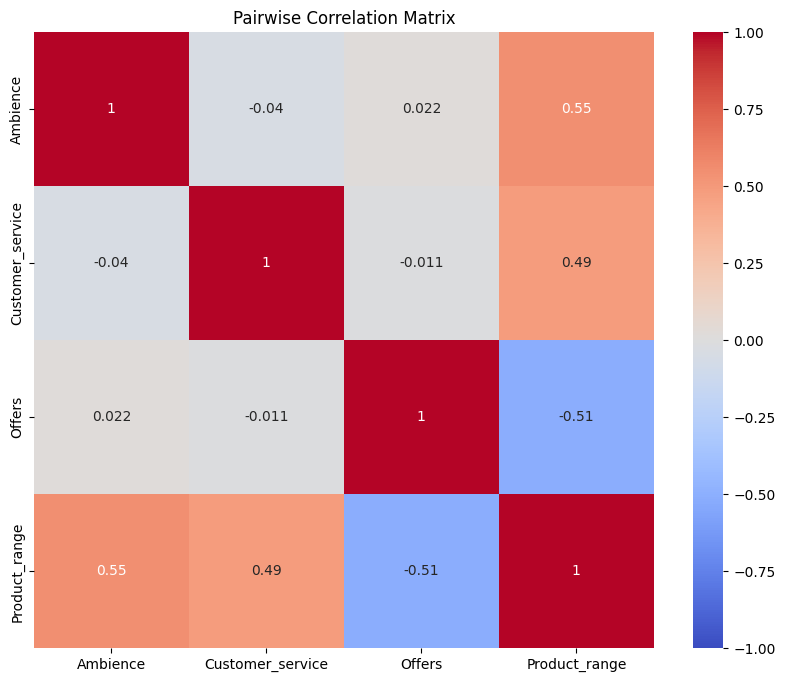

In [10]:
correl_data = retail_data[['Ambience', 'Customer_service', 'Offers', 'Product_range']]

# Compute the pairwise correlation matrix
corr_matrix = correl_data.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pairwise Correlation Matrix')
plt.show()

<Axes: xlabel='Ambience', ylabel='Offers'>

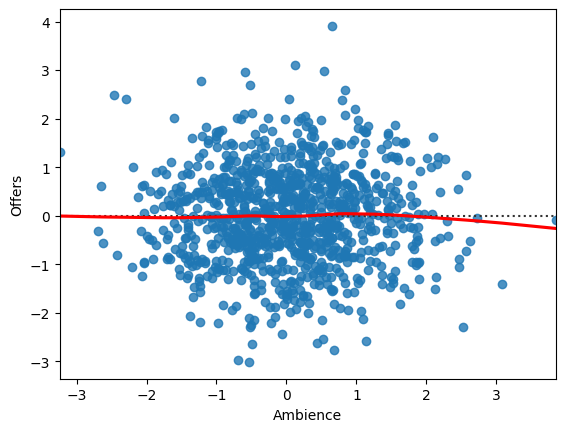

In [11]:
sns.residplot(data=retail_data, x="Ambience", y="Offers", lowess=True, line_kws=dict(color="r"))

In [12]:
# Define the predictor variables
X = retail_data.drop(columns=['Performance'])

# Add a constant to the model (intercept)
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

            Feature       VIF
0             const  1.005825
1          Ambience  3.007933
2  Customer_service  2.543664
3            Offers  2.582033
4     Product_range  5.942743


Inference of the VIF result: From the higher VIF of **Product_range** it is clear that, is that the **Product_range** variable is exhibiting multicollinearity.



**Lab Experiment 5-b**. Calculate VIF manually for the above dataset

In [ ]:
retail_data = retail_data.drop(columns=['Performance'])

# Manual VIF Calculation
vif_manual = {}

for feature in retail_data.columns:
    # Define the target variable (current feature) and predictors (all other features)
    y = retail_data[feature]
    X = retail_data.drop(columns=[feature])

    # Fit the linear regression model
    model = LinearRegression().fit(X, y)

    # Calculate R-squared
    r_squared = model.score(X, y)

    # Calculate VIF
    vif = 1 / (1 - r_squared)
    vif_manual[feature] = vif

# Convert the dictionary to a DataFrame for better display
vif_manual_df = pd.DataFrame(list(vif_manual.items()), columns=['Feature', 'VIF'])
print(vif_manual_df)

            Feature       VIF
0          Ambience  3.007933
1  Customer_service  2.543664
2            Offers  2.582033
3     Product_range  5.942743


Interpretation of VIF output: The output shows each feature along with its VIF value, helping to identify potential multicollinearity issues. You can see the result is obviously the same as we got above; and so will be its interpretation, which is that the **Product_range** variable is exhibiting multicollinearity.